# Survival HTE Examples: Heterogeneous Treatment Effects with Censored Outcomes

This notebook demonstrates three approaches to estimating heterogeneous treatment effects (CATE) when outcomes are right-censored survival times:

1. **Approach A — Direct survival methods**: Fit survival models on raw `(time, event)` data and compute RMST-based CATE (SurvivalTLearner, SurvivalSLearner, CausalSurvivalForest)
2. **Approach B — CUT transform + generic learners**: Transform censored outcomes into scalar pseudo-outcomes via IPCW/BJ/AIPCW, then use any standard EconML CATE estimator (TLearner, SLearner, CausalForest, UIF)
3. **Approach C — CUT transform + outcome-transform learners**: Use AIPCW pseudo-outcomes with learners that construct their own pseudo-outcomes internally (XLearner, AIPTWLearner, RLearner)

The data generating process mirrors `original/simulation/survival/survival_hte_simulation_case1.R`.

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

# EconML imports
import econml.metalearners._censor_metalearners as _censor_metalearners
_censor_metalearners = importlib.reload(_censor_metalearners)
TLearner = _censor_metalearners.TLearner
SLearner = _censor_metalearners.SLearner
XLearner = _censor_metalearners.XLearner
SurvivalTLearner = _censor_metalearners.SurvivalTLearner
SurvivalSLearner = _censor_metalearners.SurvivalSLearner
IPTWLearner = _censor_metalearners.IPTWLearner
AIPTWLearner = _censor_metalearners.AIPTWLearner
MCLearner = _censor_metalearners.MCLearner
MCEALearner = _censor_metalearners.MCEALearner
ULearner = _censor_metalearners.ULearner
RALearner = _censor_metalearners.RALearner
RLearner = _censor_metalearners.RLearner
IFLearner = _censor_metalearners.IFLearner

import econml.grf._causal_survival_forest as _causal_survival_forest
_causal_survival_forest = importlib.reload(_causal_survival_forest)
CausalSurvivalForest = _causal_survival_forest.CausalSurvivalForest
from econml.grf import GRFCausalForest as CausalForest
from econml.censor import (
    fit_nuisance_survival_crossfit,
    ipcw_cut_rmst, bj_cut_rmst, aipcw_cut_rmst,
    uif_diff_rmst,
)

# DGP (ported from R simulation)
from econml.tests.test_censor.dgp import make_survival_data

%matplotlib inline


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Generating Process

We generate survival data with:
- 6 covariates (3 correlated continuous, 3 binary)
- Logistic propensity score
- Counterfactual event times: log-logistic (a=0), log-normal (a=1)
- Treatment-dependent censoring
- Administrative censoring at t=10
- True CATE = RMST(a=1|X, tau) - RMST(a=0|X, tau) via Monte Carlo

In [2]:
tau = 4.0
data = make_survival_data(n=2000, tau=tau, seed=42, compute_true_cate=True)

X = data['X']
T = data['T']
time = data['time']
event = data['event']
true_cate = data['true_cate']
surv_obj = data['Y']  # structured array for survival learners

clip_hte = lambda y: np.clip(np.asarray(y, dtype=float).ravel(), -2 * tau, 2 * tau)

n = len(T)
print(f"n={n}, d={X.shape[1]}, tau={tau}")
print(f"Treatment rate: {T.mean():.2f}")
print(f"Censoring rate: {1 - event.mean():.2f}")
print(f"True ATE (RMST diff): {true_cate.mean():.3f}")

n=2000, d=6, tau=4.0
Treatment rate: 0.48
Censoring rate: 0.32
True ATE (RMST diff): -0.375


In [3]:
# Notebook-level outer sample splitting is intentionally omitted.
# Reported CATEs come directly from each estimator's own prediction path.


## 2. Approach A — Direct Survival Methods

These methods take raw `(event, time)` structured arrays and internally fit survival models. No CUT transformation step needed.

- **SurvivalTLearner / SurvivalSLearner**: Fit scikit-survival models (CoxPH) and report RMST differences from the fitted estimators
- **CausalSurvivalForest**: GRF-style honest forest with doubly-robust survival pseudo-outcomes computed internally

In [4]:
# Survival methods: fit once on the full sample and query estimator effects

surv_s = SurvivalSLearner(
    tau=tau,
    cv=2,
)
surv_s.fit(surv_obj, T, X=X)
cate_surv_s = clip_hte(surv_s.effect(X))

surv_t = SurvivalTLearner(
    tau=tau,
    cv=2,
)
surv_t.fit(surv_obj, T, X=X)
cate_surv_t = clip_hte(surv_t.effect(X))

csf = CausalSurvivalForest(tau=tau, n_estimators=200, nuisance_cv=2, random_state=42)
csf.fit(X, T, time, event.astype(bool))
cate_csf = clip_hte(csf.effect(X))

print(f"SurvivalSLearner ATE: {cate_surv_s.mean():.3f}")
print(f"SurvivalTLearner ATE: {cate_surv_t.mean():.3f}")
print(f"CausalSurvivalForest ATE:  {cate_csf.mean():.3f}")


SurvivalSLearner ATE: -0.223
SurvivalTLearner ATE: -0.233
CausalSurvivalForest ATE:  -0.258


## 3. Approach B — CUT Transforms + Generic Learners

Two-step pipeline:
1. **Cross-fit nuisance models** (censoring `G`, event `S`, and propensity `ps`) and **apply CUT/UIF transforms** to get scalar pseudo-outcomes
2. **Feed pseudo-outcomes** into any standard EconML learner (TLearner, SLearner, CausalForest)

### 3a. Cross-fit nuisance models and apply transforms


In [5]:
# Cross-fit G(t|a,X), S(t|a,X), and ps(X) using held-out folds
nuis = fit_nuisance_survival_crossfit(
    time, event.astype(int), T, X,
    model_cause=None,
    model_competing=None,
    cv=2,
    random_state=42)

print(f"Time grid: {len(nuis.time_grid)} points")
print(f"G_a0 shape: {nuis.G_a0.shape}")
print(f"S_a0 shape: {nuis.S_a0.shape}")
print(f"ps range: [{nuis.ps.min():.3f}, {nuis.ps.max():.3f}]")


Time grid: 635 points
G_a0 shape: (2000, 635)
S_a0 shape: (2000, 635)
ps range: [0.080, 0.942]


In [6]:
# Apply three CUT transforms → scalar pseudo-outcomes
Y_ipcw = ipcw_cut_rmst(T, time, event, tau,
                       nuis.G_a0, nuis.G_a1,
                       time_grid=nuis.time_grid)

Y_bj = bj_cut_rmst(T, time, event, tau,
                    nuis.S_a0, nuis.S_a1,
                    time_grid=nuis.time_grid)

Y_aipcw = aipcw_cut_rmst(T, time, event, tau,
                         nuis.G_a0, nuis.G_a1,
                         nuis.S_a0, nuis.S_a1,
                         time_grid=nuis.time_grid)

print(f"IPCW pseudo-outcome: mean={Y_ipcw.mean():.3f}, std={Y_ipcw.std():.3f}")
print(f"BJ pseudo-outcome:   mean={Y_bj.mean():.3f}, std={Y_bj.std():.3f}")
print(f"AIPCW pseudo-outcome: mean={Y_aipcw.mean():.3f}, std={Y_aipcw.std():.3f}")

IPCW pseudo-outcome: mean=2.425, std=2.362
BJ pseudo-outcome:   mean=2.490, std=1.472
AIPCW pseudo-outcome: mean=2.472, std=1.518


### 3b. Feed pseudo-outcomes into generic EconML learners

After the CUT step, `Y_star` is a plain float array. Any existing EconML estimator works directly.

All three transforms are available — `Y_ipcw` (singly robust, requires correct censoring model),
`Y_bj` (singly robust, requires correct event model), and `Y_aipcw` (doubly robust, recommended).
Below we use `Y_aipcw` for the learner comparisons.

In [7]:
# Use AIPCW pseudo-outcome (doubly robust) and fit each learner on the full sample
# Y_ipcw and Y_bj are also available as singly-robust alternatives
results = {}

tl_est = TLearner(cv=2)
tl_est.fit(Y_aipcw, T, X=X)
results["AIPCW + TLearner"] = clip_hte(tl_est.effect(X))

sl_est = SLearner(cv=2)
sl_est.fit(Y_aipcw, T, X=X)
results["AIPCW + SLearner"] = clip_hte(sl_est.effect(X))

cf_est = CausalForest(num_trees=200, seed=42)
cf_est.fit(X, Y_aipcw, T)
results["AIPCW + CausalForest"] = clip_hte(cf_est.effect(X))

print("ATEs:")
for k, v in results.items():
    print(f"  {k:35s}: {v.mean():.3f}")


ATEs:
  AIPCW + TLearner                   : -0.225
  AIPCW + SLearner                   : -0.230
  AIPCW + CausalForest               : -0.233


### 3c. IFLearner (Uncentered Influence Function)

The UIF transform (`uif_diff_rmst`) produces per-subject pseudo-outcomes.
`IFLearner` regresses these scores on X — mirroring `uif_learner()` from `hte_learners.R`.
Here the balancing and tilting weights are also taken from the cross-fitted nuisance step.
The raw UIF scores (`UIF (direct)`) are also kept as a reference (population-level estimate).


In [8]:
# UIF: use cross-fitted balancing and tilting weights
# For ATE estimation: bw = 1/(ps*a + (1-ps)*(1-a)), tilt = 1
bw = nuis.iptw
tilt = nuis.naive

Y_uif_diff_rmst = uif_diff_rmst(T, time, event, tau, bw, tilt,
                      nuis.G_a0, nuis.G_a1,
                      nuis.S_a0, nuis.S_a1,
                      time_grid=nuis.time_grid)

# IFLearner: fit on the precomputed UIF score and query estimator effects
if_est = IFLearner(cv=2)
if_est.fit(Y_uif_diff_rmst, X=X)
results["IFLearner"] = clip_hte(if_est.effect(X))

# Raw UIF scores (direct, population-level reference)
raw_if_score = Y_uif_diff_rmst
print(f"IFLearner ATE:    {results['IFLearner'].mean():.3f}")
print(f"Raw IF ATE: {raw_if_score.mean():.3f}")


IFLearner ATE:    -0.264
Raw IF ATE: -0.252


## 4. Approach C — CUT Transforms + Outcome-Transform Learners

These learners build their own internal pseudo-outcomes on top of the AIPCW CUT pseudo-outcome `Y*`.

### Outcome-transform learners (XLearner, AIPTWLearner, RLearner, IPTW, MC, MCEA, U-learner)

In [9]:
# Outcome-transform learners: fit once on the full sample and query estimator effects
xl_est = XLearner(cv=2)
xl_est.fit(Y_aipcw, T, X=X)
results["AIPCW + XLearner"] = clip_hte(xl_est.effect(X))

aiptw_est = AIPTWLearner(cv=2)
aiptw_est.fit(Y_aipcw, T, X=X)
results["AIPCW + AIPTWLearner"] = clip_hte(aiptw_est.effect(X))

r_est = RLearner(cv=2)
r_est.fit(Y_aipcw, T, X=X)
results["AIPCW + RLearner"] = clip_hte(r_est.effect(X))

iptw_est = IPTWLearner(cv=2)
iptw_est.fit(Y_aipcw, T, X=X)
results["AIPCW + IPTWLearner"] = clip_hte(iptw_est.effect(X))

mc_est = MCLearner(cv=2)
mc_est.fit(Y_aipcw, T, X=X)
results["AIPCW + MCLearner"] = clip_hte(mc_est.effect(X))

mcea_est = MCEALearner(cv=2)
mcea_est.fit(Y_aipcw, T, X=X)
results["AIPCW + MCEALearner"] = clip_hte(mcea_est.effect(X))

u_est = ULearner(cv=2)
u_est.fit(Y_aipcw, T, X=X)
results["AIPCW + ULearner"] = clip_hte(u_est.effect(X))

ra_est = RALearner(cv=2)
ra_est.fit(Y_aipcw, T, X=X)
results["AIPCW + RALearner"] = clip_hte(ra_est.effect(X))

print("Approach C ATEs:")
for k in ["AIPCW + XLearner", "AIPCW + AIPTWLearner", "AIPCW + RLearner",
          "AIPCW + IPTWLearner", "AIPCW + MCLearner",
          "AIPCW + MCEALearner", "AIPCW + ULearner",
          "AIPCW + RALearner"]:
    print(f"  {k:35s}: {results[k].mean():.3f}")


Approach C ATEs:
  AIPCW + XLearner                   : -0.267
  AIPCW + AIPTWLearner               : -0.229
  AIPCW + RLearner                   : -0.185
  AIPCW + IPTWLearner                : -0.533
  AIPCW + MCLearner                  : -0.022
  AIPCW + MCEALearner                : -0.224
  AIPCW + ULearner                   : -0.266
  AIPCW + RALearner                  : -0.237


## 5. Evaluation & Comparison

Compare all method predictions against the Monte Carlo true CATE.

In [10]:
# Collect all learner CATE estimates
all_results = {
    "SurvivalTLearner": cate_surv_t,
    "SurvivalSLearner": cate_surv_s,
    **results,
    "CausalSurvivalForest": cate_csf,
}

# Bias and RMSE table
print("{:35s} {:>7s} {:>7s} {:>7s}".format("Method", "ATE", "Bias", "RMSE"))
print("-" * 60)
for name, cate_hat in all_results.items():
    bias = np.mean(cate_hat - true_cate)
    rmse = np.sqrt(np.mean((cate_hat - true_cate) ** 2))
    ate = np.mean(cate_hat)
    print(f"{name:35s} {ate:7.3f} {bias:7.3f} {rmse:7.3f}")
print("{:35s} {:7.3f}".format("True ATE", true_cate.mean()))


Method                                  ATE    Bias    RMSE
------------------------------------------------------------
SurvivalTLearner                     -0.233   0.142   0.875
SurvivalSLearner                     -0.223   0.152   1.021
AIPCW + TLearner                     -0.225   0.150   0.825
AIPCW + SLearner                     -0.230   0.145   1.094
AIPCW + CausalForest                 -0.233   0.142   0.649
IFLearner                            -0.264   0.111   0.721
AIPCW + XLearner                     -0.267   0.108   0.706
AIPCW + AIPTWLearner                 -0.229   0.146   0.789
AIPCW + RLearner                     -0.185   0.189   0.772
AIPCW + IPTWLearner                  -0.533  -0.159   1.784
AIPCW + MCLearner                    -0.022   0.353   1.812
AIPCW + MCEALearner                  -0.224   0.150   0.766
AIPCW + ULearner                     -0.266   0.109   0.962
AIPCW + RALearner                    -0.237   0.138   0.676
CausalSurvivalForest                 -0

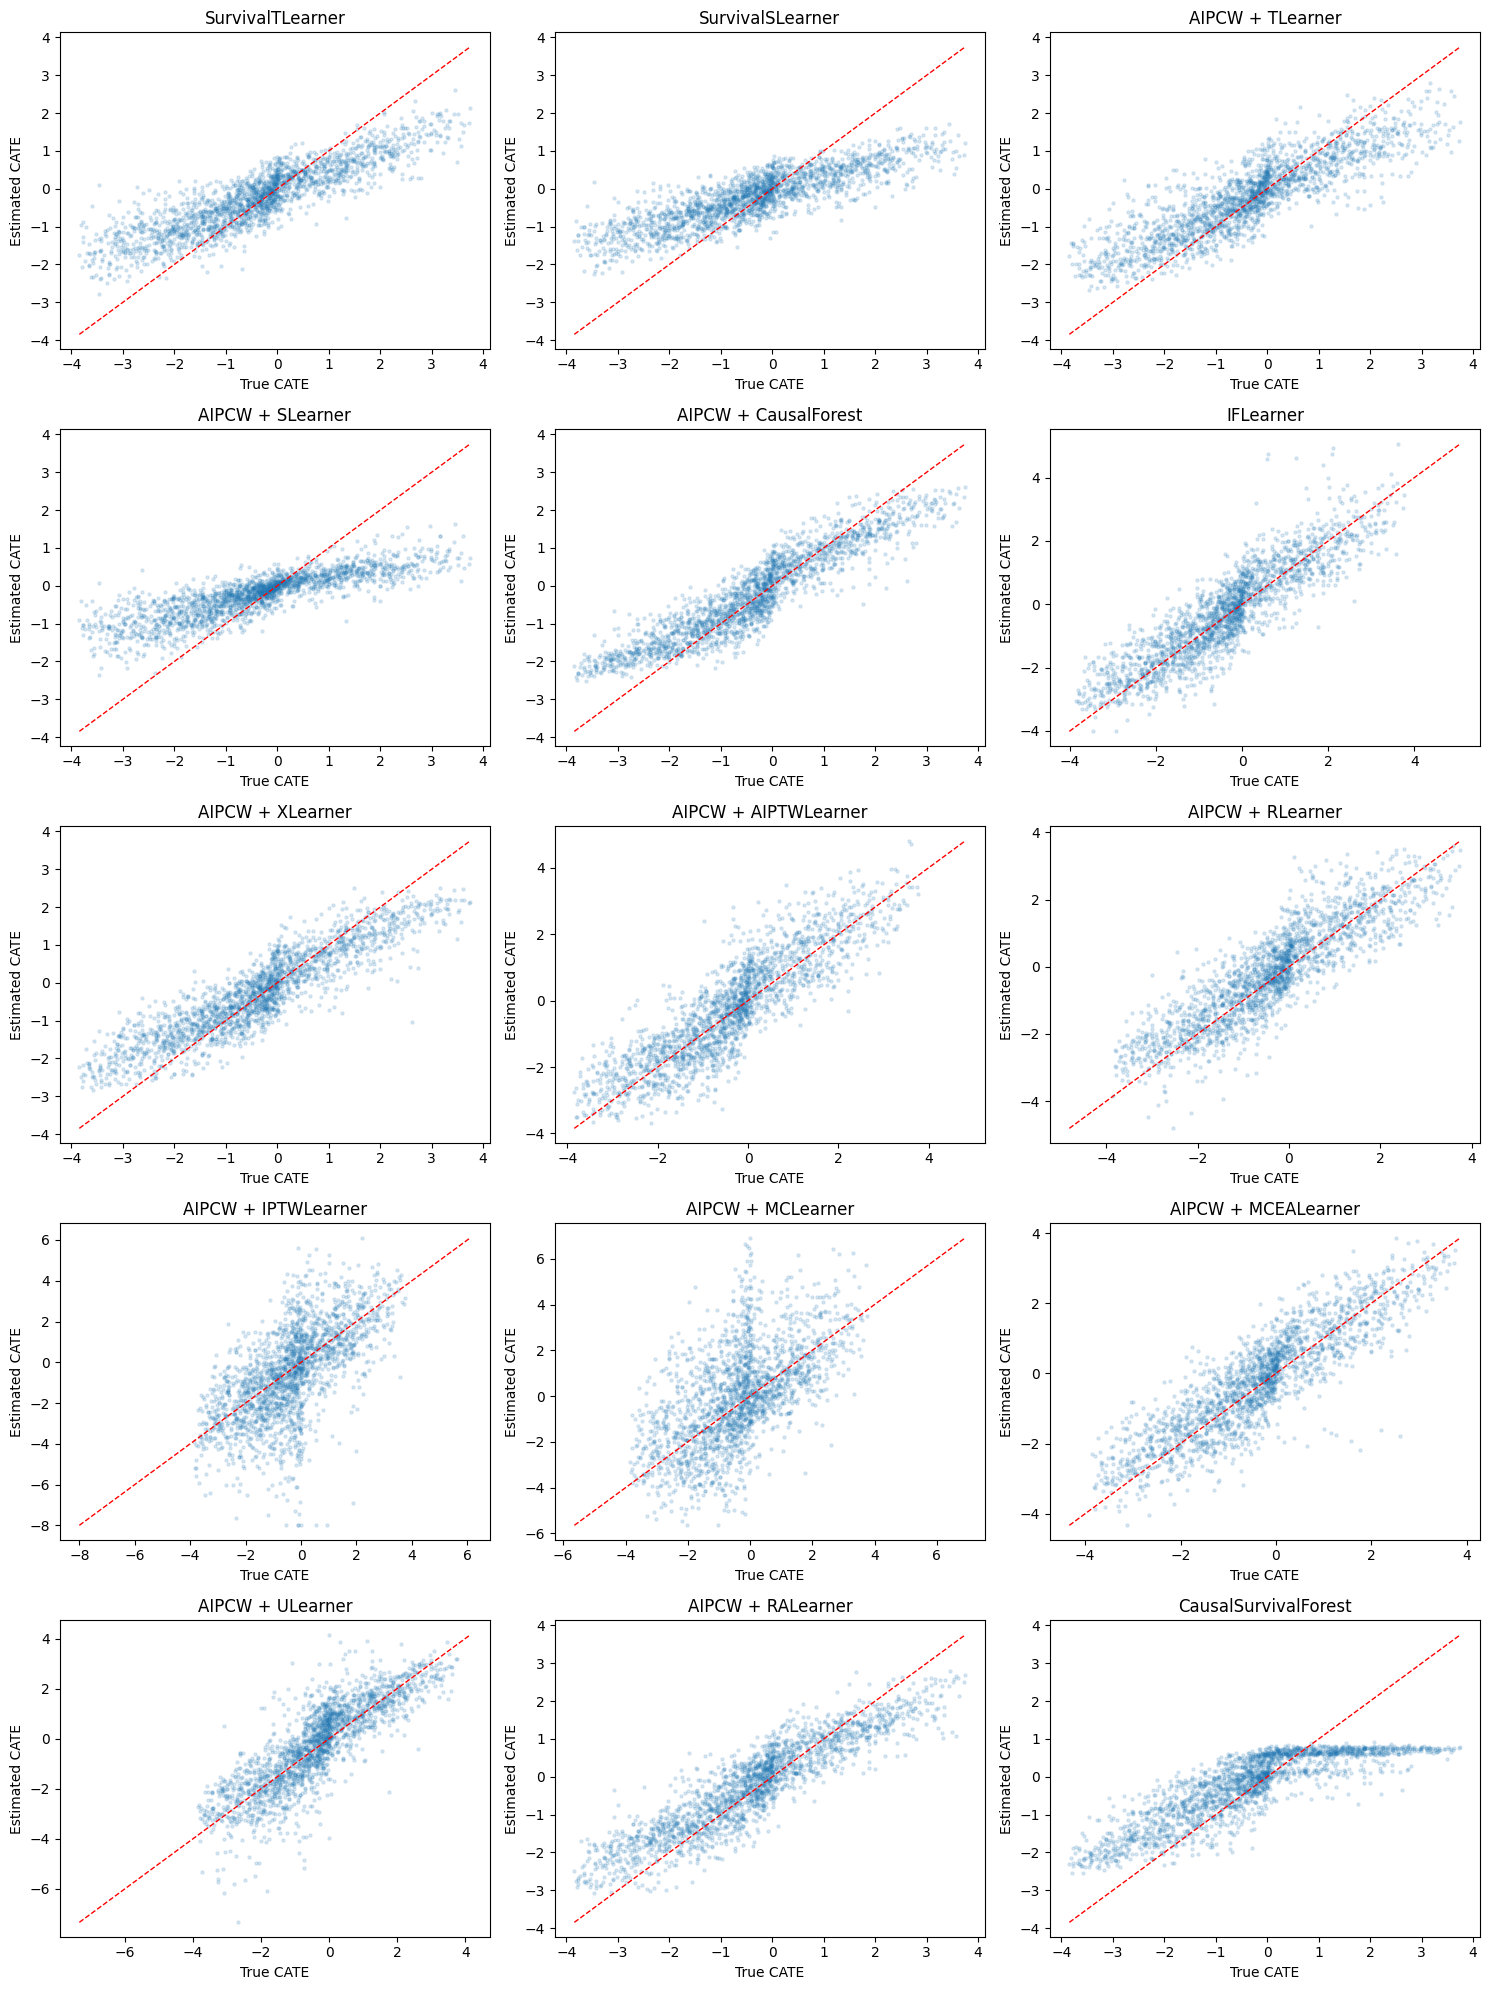

In [11]:
# Scatter: estimated CATE vs true CATE for all learners
names = list(all_results.keys())
n_cols = 3
n_rows = int(np.ceil(len(names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, names):
    cate_hat = all_results[name]
    ax.scatter(true_cate, cate_hat, alpha=0.15, s=5)
    lims = [min(true_cate.min(), cate_hat.min()), max(true_cate.max(), cate_hat.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('True CATE')
    ax.set_ylabel('Estimated CATE')
    ax.set_title(name)

for ax in axes[len(names):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


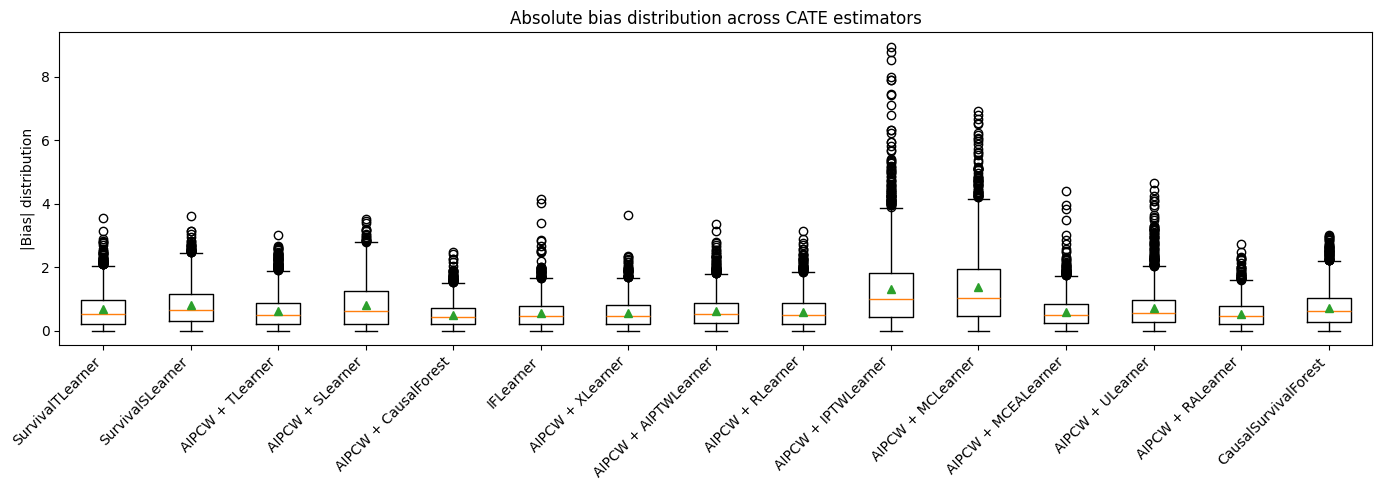

In [12]:
# Boxplot of |bias| distribution across methods
names = list(all_results.keys())
biases = [np.abs(all_results[k] - true_cate) for k in names]

plt.figure(figsize=(14, 5))
plt.boxplot(biases, showmeans=True)
plt.xticks(range(1, len(names) + 1), names, rotation=45, ha='right')
plt.ylabel('|Bias| distribution')
plt.title('Absolute bias distribution across CATE estimators')
plt.tight_layout()
plt.show()


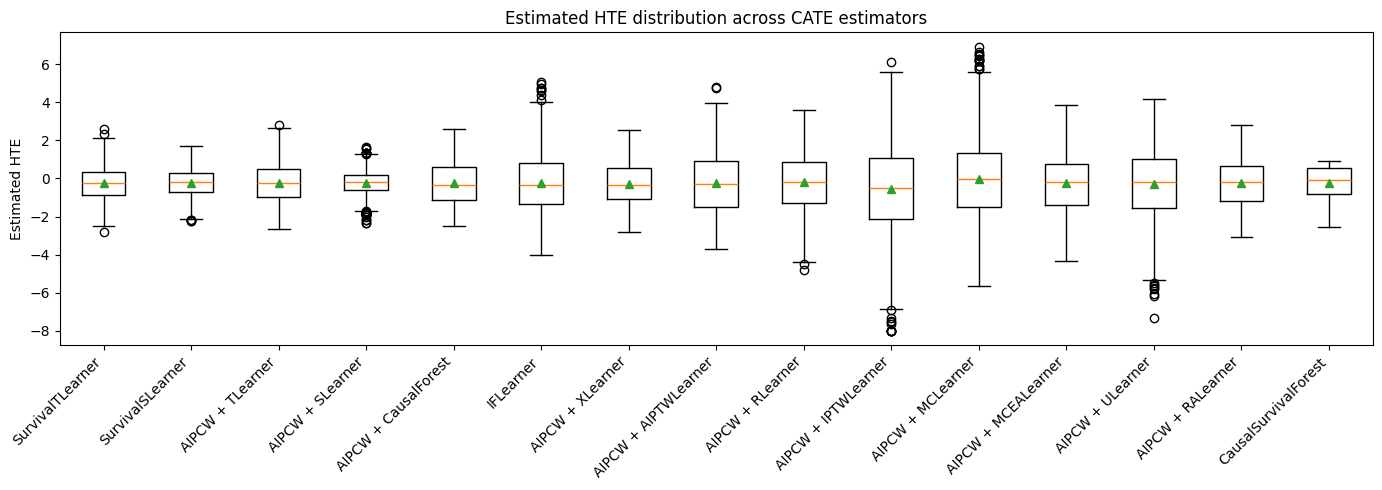

In [13]:
# Boxplot of estimated HTE distributions across methods
names = list(all_results.keys())
hte_values = [np.asarray(all_results[k]).ravel() for k in names]

plt.figure(figsize=(14, 5))
plt.boxplot(hte_values, showmeans=True)
plt.xticks(range(1, len(names) + 1), names, rotation=45, ha='right')
plt.ylabel('Estimated HTE')
plt.title('Estimated HTE distribution across CATE estimators')
plt.tight_layout()
plt.show()
